# Chapter 3: Statistical Experiments and Significance Testing

## Practical Statistics for Data Scientists

Penulis:
Peter Bruce, Andrew Bruce, Peter Gedeck


## Pendahuluan

Eksperimen statistik digunakan untuk mengetahui apakah perubahan
suatu perlakuan memberikan pengaruh terhadap hasil yang diamati.

Dalam data science, eksperimen sering digunakan untuk:

- menguji desain website,
- membandingkan strategi pemasaran,
- mengevaluasi perubahan sistem,
- menentukan keputusan berdasarkan data.

Chapter ini membahas metode statistik untuk menentukan apakah
perbedaan yang ditemukan dalam data merupakan efek nyata atau
hanya terjadi karena variasi acak.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats import power

# A/B Testing

A/B testing merupakan metode eksperimen yang membandingkan dua versi
perlakuan.

Kelompok:

A:
Kelompok kontrol yang menggunakan kondisi awal.

B:
Kelompok eksperimen yang menggunakan perubahan baru.


Contoh:

Sebuah perusahaan ingin mengetahui apakah desain halaman website baru
dapat meningkatkan jumlah klik pengguna.

In [2]:
web_page = pd.read_csv(
    "data/web_page_data.csv"
)

web_page.head()

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


In [4]:
web_page.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Page    36 non-null     object 
 1   Time    36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 704.0+ bytes


Dataset memiliki variabel:

Page:
Menunjukkan versi halaman website.

Time:
Menunjukkan waktu pengguna berada pada halaman.

Data ini digunakan untuk membandingkan perilaku pengguna
antara halaman kontrol dan halaman baru.

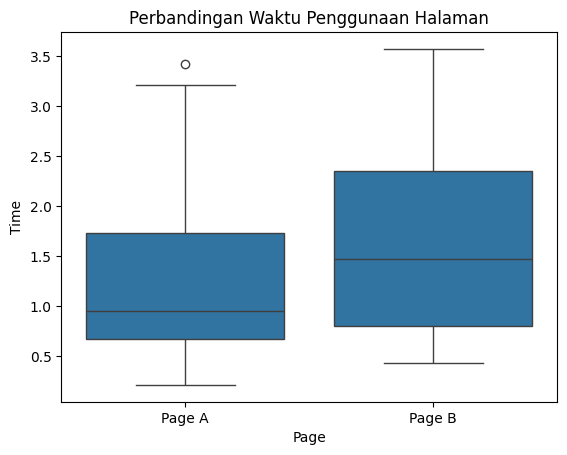

In [5]:
sns.boxplot(
    data=web_page,
    x="Page",
    y="Time"
)

plt.title(
    "Perbandingan Waktu Penggunaan Halaman"
)

plt.show()

In [6]:
web_page.groupby(
    "Page"
)["Time"].mean()

Page
Page A    1.263333
Page B    1.620000
Name: Time, dtype: float64

Perbedaan nilai rata-rata antara dua halaman menunjukkan adanya
perbedaan perilaku pengguna.

Namun, perbedaan tersebut perlu diuji secara statistik untuk mengetahui
apakah perubahan benar-benar memberikan pengaruh.

# Hypothesis Testing

Pengujian hipotesis digunakan untuk mengambil keputusan berdasarkan
bukti statistik.

Terdapat dua hipotesis:

## Null Hypothesis (H0)

Menyatakan bahwa tidak terdapat perbedaan.

Contoh:
Tidak ada perbedaan waktu penggunaan antara Page A dan Page B.


## Alternative Hypothesis (H1)

Menyatakan bahwa terdapat perbedaan.

# Permutation Test

Permutation test merupakan metode resampling yang digunakan untuk
menguji apakah perbedaan dua kelompok terjadi secara kebetulan.

Tahapan:

1. Menggabungkan seluruh data.
2. Mengacak label kelompok.
3. Menghitung perbedaan rata-rata.
4. Membandingkan hasil simulasi dengan nilai asli.

In [7]:
mean_a = (
    web_page[
        web_page["Page"]=="Page A"
    ]["Time"]
    .mean()
)


mean_b = (
    web_page[
        web_page["Page"]=="Page B"
    ]["Time"]
    .mean()
)


observed_difference = mean_b - mean_a

observed_difference

0.3566666666666669

In [8]:
def permutation_test(data, column, group, iterations=1000):

    observed = (
        data.groupby(group)[column]
        .mean()
        .diff()
        .iloc[-1]
    )

    results = []

    values = data[column].values.copy()

    groups = data[group].values.copy()


    for i in range(iterations):

        np.random.shuffle(groups)

        temp = pd.DataFrame({
            column: values,
            group: groups
        })


        diff = (
            temp.groupby(group)[column]
            .mean()
            .diff()
            .iloc[-1]
        )

        results.append(diff)


    return observed, np.array(results)

In [9]:
observed, permutation = permutation_test(
    web_page,
    "Time",
    "Page"
)

observed

0.3566666666666667

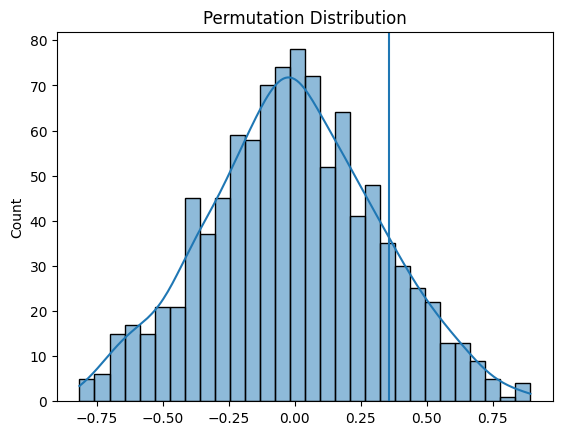

In [10]:
sns.histplot(
    permutation,
    bins=30,
    kde=True
)


plt.axvline(
    observed
)


plt.title(
    "Permutation Distribution"
)

plt.show()

# p-value

p-value menunjukkan kemungkinan memperoleh hasil seperti observasi
apabila hipotesis nol benar.

Nilai p-value kecil menunjukkan bahwa hasil observasi sulit dijelaskan
hanya melalui variasi acak.

In [11]:
p_value = np.mean(
    np.abs(permutation)
    >=
    abs(observed)
)

p_value

0.28

# t-Test

t-Test digunakan untuk membandingkan rata-rata dua kelompok.

Jenis umum:

- Independent t-test
- Paired t-test

In [12]:
group_a = web_page[
    web_page["Page"]=="Page A"
]["Time"]


group_b = web_page[
    web_page["Page"]=="Page B"
]["Time"]


stats.ttest_ind(
    group_a,
    group_b
)

Ttest_indResult(statistic=-1.1237042154424823, pvalue=0.26901024363926024)

# Multiple Testing

Jika banyak pengujian dilakukan secara bersamaan,
kemungkinan mendapatkan hasil signifikan secara kebetulan meningkat.

Karena itu diperlukan pengendalian tingkat kesalahan statistik.

# ANOVA

Analysis of Variance digunakan untuk membandingkan rata-rata
lebih dari dua kelompok.

ANOVA menguji apakah terdapat minimal satu kelompok yang memiliki
rata-rata berbeda.

In [13]:
four_sessions = pd.read_csv(
    "data/four_sessions.csv"
)

four_sessions.head()

,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172


In [14]:
four_sessions.groupby(
    "Page"
)["Time"].mean()

Page
Page 1    172.8
Page 2    182.6
Page 3    175.6
Page 4    164.6
Name: Time, dtype: float64

In [15]:
model = smf.ols(
    "Time ~ Page",
    data=four_sessions
).fit()


anova_result = sm.stats.anova_lm(
    model
)

anova_result

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


## Interpretasi Hasil ANOVA

Hasil ANOVA menunjukkan nilai F-statistic dan p-value.

Jika p-value < 0.05:

Terdapat perbedaan waktu sesi yang signifikan antar halaman.

Jika p-value > 0.05:

Tidak terdapat bukti yang cukup bahwa halaman memiliki perbedaan
rata-rata waktu sesi.

# Chi-Square Test

Chi-Square Test digunakan untuk mengetahui hubungan antara dua
variabel kategorikal.

Berbeda dengan t-test dan ANOVA yang membandingkan rata-rata variabel
numerik, Chi-Square digunakan untuk menganalisis frekuensi kategori.

Contoh pertanyaan:

Apakah terdapat hubungan antara jenis kelompok pengguna dengan
hasil eksperimen?

Hipotesis:

H0:
Tidak terdapat hubungan antara kedua variabel kategorikal.

H1:
Terdapat hubungan antara kedua variabel kategorikal.

In [17]:
click_rates = pd.read_csv(
    "data/click_rates.csv"
)

click_rates.head()

,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12


In [19]:
contingency_table = pd.crosstab(
    click_rates["Headline"],
    click_rates["Click"]
)

contingency_table

Click,Click,No-click
Headline,,
Headline A,1,1
Headline B,1,1
Headline C,1,1


In [20]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)


print(
    "Chi-square:",
    chi2
)

print(
    "p-value:",
    p_value
)

Chi-square: 0.0
p-value: 1.0


## Interpretasi

Nilai p-value digunakan untuk menentukan apakah hubungan antar
variabel kategorikal signifikan.

Jika p-value < 0.05:

H0 ditolak, sehingga terdapat hubungan yang signifikan antar variabel.

Jika p-value > 0.05:

H0 tidak dapat ditolak, sehingga belum terdapat bukti hubungan
yang signifikan.

# Power Analysis

Power menunjukkan kemampuan suatu pengujian dalam mendeteksi
perbedaan yang benar-benar terjadi.

Power dipengaruhi oleh:

- ukuran sampel,
- besar efek,
- tingkat signifikansi.

In [16]:
analysis = power.TTestIndPower()


sample_size = analysis.solve_power(
    effect_size=0.5,
    alpha=0.05,
    power=0.8
)

sample_size

63.76561177540986

# Kesimpulan Chapter 3

Chapter 3 membahas bagaimana eksperimen statistik digunakan untuk
menguji hubungan sebab akibat berdasarkan data.

Konsep utama:

1. A/B testing digunakan untuk membandingkan dua perlakuan.
2. Hypothesis testing digunakan untuk menguji klaim statistik.
3. Permutation test digunakan untuk mengukur signifikansi perbedaan.
4. p-value membantu menentukan keputusan statistik.
5. t-Test digunakan untuk membandingkan dua kelompok.
6. ANOVA digunakan untuk membandingkan beberapa kelompok.
7. Chi-square digunakan untuk data kategorikal.
8. Power analysis membantu menentukan kebutuhan sampel.

Metode statistik membantu memastikan keputusan berbasis data
memiliki dasar analisis yang kuat.